Shortest distances from A: {'A': 0, 'B': 4, 'C': 1, 'D': 3, 'E': 5, 'F': 9, 'G': 9, 'H': 10}
Shortest path A → H: ['A', 'C', 'D', 'E', 'H']


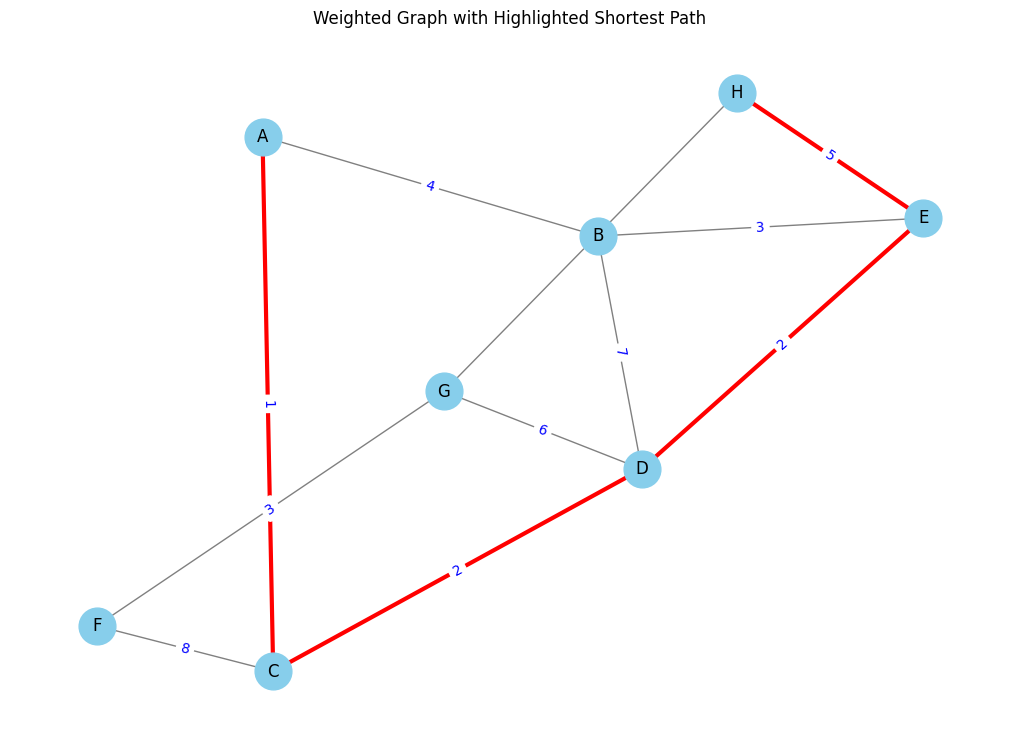

In [ ]:
# weighted graph
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    path = {node: None for node in graph}
    pq = [(0, start)]

    while pq:
        current_distance, current_node = heapq.heappop(pq)

        # Optimization: If the current distance is greater than the recorded distance, skip
        if current_distance > distances[current_node]:
            continue

        for neighbor, weight in graph[current_node].items():
            new_distance = current_distance + weight
            if new_distance < distances[neighbor]:
                distances[neighbor] = new_distance
                path[neighbor] = current_node
                heapq.heappush(pq, (new_distance, neighbor))

    return distances, path

def get_shortest_path(path, start, end):
    """
    Reconstructs the shortest path from the predecessors dictionary.
    Args:
        path (dict): The predecessors dictionary returned by dijkstra().
        start (str): The start node.
        end (str): The end node.
    Returns:
        list: The sequence of nodes forming the shortest path.
    """
    route = []
    current = end
    while current is not None:
        route.append(current)
        current = path[current]
    route.reverse()

    # Check if a path was found
    if route[0] == start:
        return route
    else:
        return [] # Return empty list if no path exists

def draw_graph_with_path(graph, shortest_path):
    """
    Draws the graph using NetworkX and Matplotlib, highlighting the shortest path.
    Args:
        graph (dict): The adjacency list representation of the graph.
        shortest_path (list): The list of nodes in the shortest path.
    """
    G = nx.Graph()
    for node, edges in graph.items():
        for neighbor, weight in edges.items():
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(G) # Position nodes using Fruchterman-Reingold force-directed algorithm
    plt.figure(figsize=(10, 7))

    # Draw all edges and nodes
    nx.draw(G, pos, with_labels=True, node_color='skyblue',
            node_size=700, edge_color='gray', width=1.0)

    # Highlight the shortest path edges
    sp_edges = [(shortest_path[i], shortest_path[i+1]) for i in
                range(len(shortest_path)-1)]
    nx.draw_networkx_edges(G, pos, edgelist=sp_edges, edge_color='red',
                           width=3.0)

    # Add edge labels (weights)
    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels,
                                  font_color='blue')

    plt.title("Weighted Graph with Highlighted Shortest Path")
    plt.axis('off') # Turn off the axis
    plt.show()

# --- Main execution block with the larger weighted graph ---
if __name__ == "__main__":
    graph = {
        'A': {'B': 4, 'C': 1},
        'B': {'A': 4, 'D': 7, 'E': 3},
        'C': {'A': 1, 'D': 2, 'F': 8},
        'D': {'B': 7, 'C': 2, 'E': 2, 'G': 6},
        'E': {'B': 3, 'D': 2, 'H': 5},
        'F': {'C': 8, 'G': 3},
        'G': {'D': 6, 'F': 3, 'H': 4},
        'H': {'E': 5, 'G': 4}
    }

    start = 'A'
    end = 'H'

    distances, path = dijkstra(graph, start)
    shortest_path = get_shortest_path(path, start, end)

    print(f"Shortest distances from {start}: {distances}")
    print(f"Shortest path {start} → {end}: {shortest_path}")

    # The drawing function will only work if networkx and matplotlib are installed
    try:
        draw_graph_with_path(graph, shortest_path)
    except ImportError:
        print("\nInstall networkx and matplotlib to visualize the graph:")
        print("pip install networkx matplotlib")